<a href="https://colab.research.google.com/github/Kishwerkhaliq/Global-Weather-Trends/blob/main/weatherTrendsDashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Replace 'my_file.csv' with the actual path to your CSV file
try:
    df = pd.read_csv('/content/drive/MyDrive/Weather Trends Dashboard/GlobalWeatherRepository.csv')
    print('CSV file read successfully. First 5 rows:')
    print(df.head())
except FileNotFoundError:
    print("Error: The file '/GlobalWeatherRepository.csv' was not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file read successfully. First 5 rows:
       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4  

# Data Cleaning

In [ ]:
print("\nDataFrame Information (Attributes):")
df.info()

print("\nMissing Values Count:")
print(df.isnull().sum())


DataFrame Information (Attributes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129808 entries, 0 to 129807
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       129808 non-null  object 
 1   location_name                 129808 non-null  object 
 2   latitude                      129808 non-null  float64
 3   longitude                     129808 non-null  float64
 4   timezone                      129808 non-null  object 
 5   last_updated_epoch            129808 non-null  int64  
 6   last_updated                  129808 non-null  object 
 7   temperature_celsius           129808 non-null  float64
 8   temperature_fahrenheit        129808 non-null  float64
 9   condition_text                129808 non-null  object 
 10  wind_mph                      129808 non-null  float64
 11  wind_kph                      129808 non-null  float64
 12  wind_de

In [ ]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  129808.000000  129808.000000        1.298080e+05        129808.000000   
mean       19.203369      21.977243        1.744734e+09            21.410327   
std        24.420767      65.788834        1.666557e+07             9.686454   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         3.870000      -6.836100        1.730365e+09            16.100000   
50%        17.250000      23.236100        1.744793e+09            24.100000   
75%        40.400000      50.580000        1.759132e+09            28.000000   
max        64.150000     179.220000        1.773644e+09            49.200000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           129808.000000  129808.000000  129808.000000  129808.000000   
mean                70.540379       8.044368      12.949763     168.972929   
std                 17.4

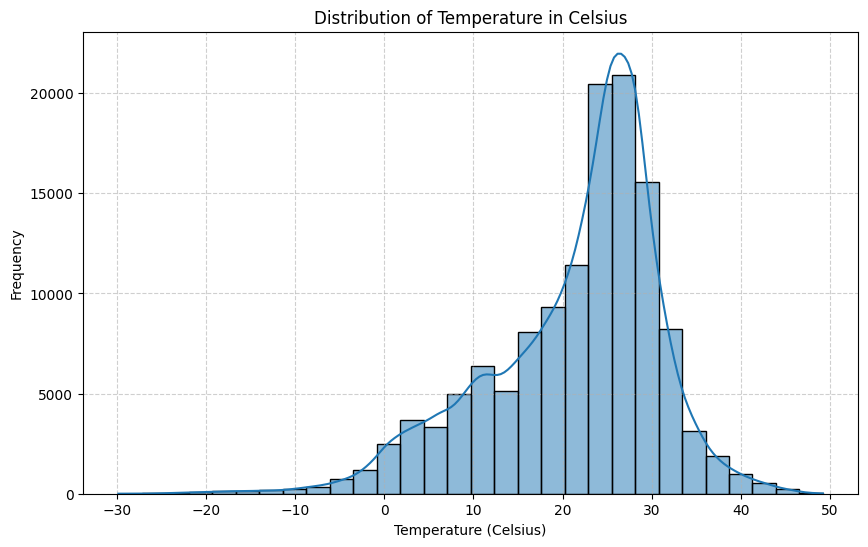

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['temperature_celsius'], kde=True, bins=30)
plt.title('Distribution of Temperature in Celsius')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

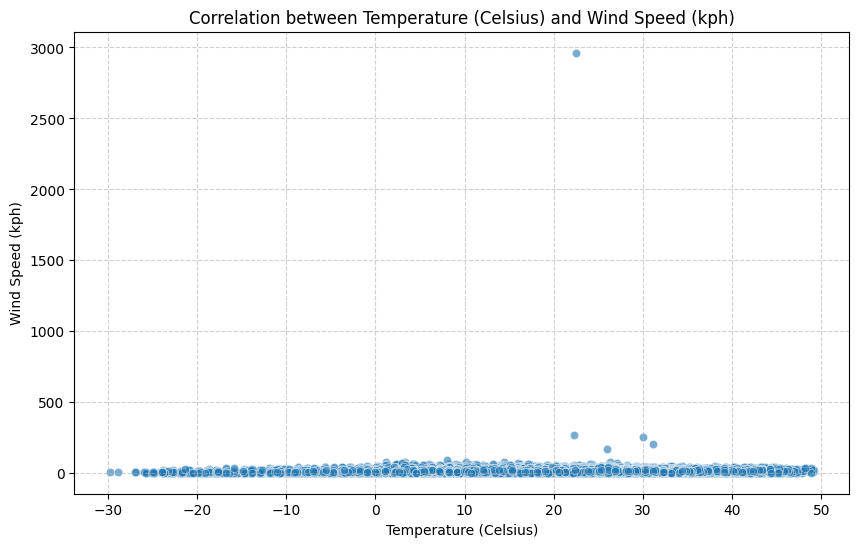

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature_celsius', y='wind_kph', data=df, alpha=0.6)
plt.title('Correlation between Temperature (Celsius) and Wind Speed (kph)')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Wind Speed (kph)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
correlation = df['temperature_celsius'].corr(df['wind_kph'])
print(f"Pearson correlation between Temperature (Celsius) and Wind Speed (kph): {correlation:.2f}")

Pearson correlation between Temperature (Celsius) and Wind Speed (kph): 0.09


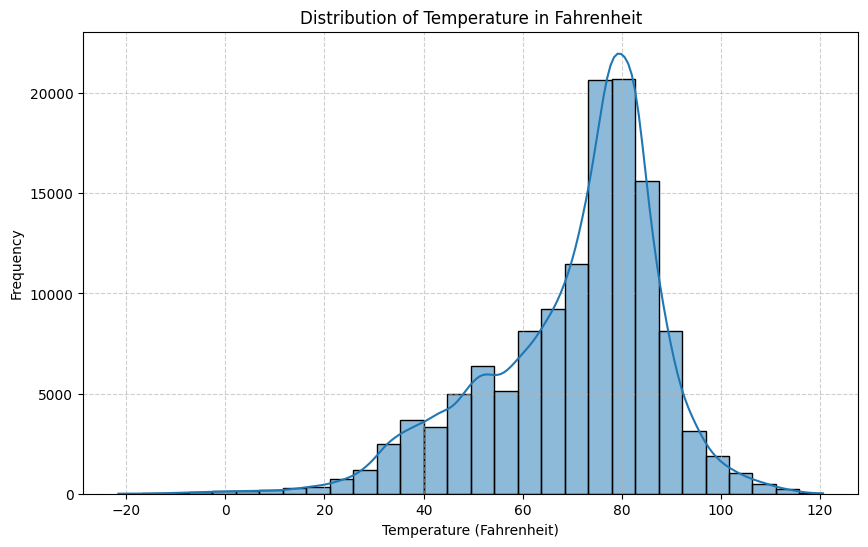

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['temperature_fahrenheit'], kde=True, bins=30)
plt.title('Distribution of Temperature in Fahrenheit')
plt.xlabel('Temperature (Fahrenheit)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Temperature

```
#  What are the hottest and coldest days in the dataset?
```




Hottest Day in the dataset:
Date: 2024-06-19
Location: Kuwait City, Kuwait
Temperature: 49.20 °C

Coldest Day in the dataset:
Date: 2026-01-18
Location: Ulaanbaatar, Mongolia
Temperature: -29.80 °C



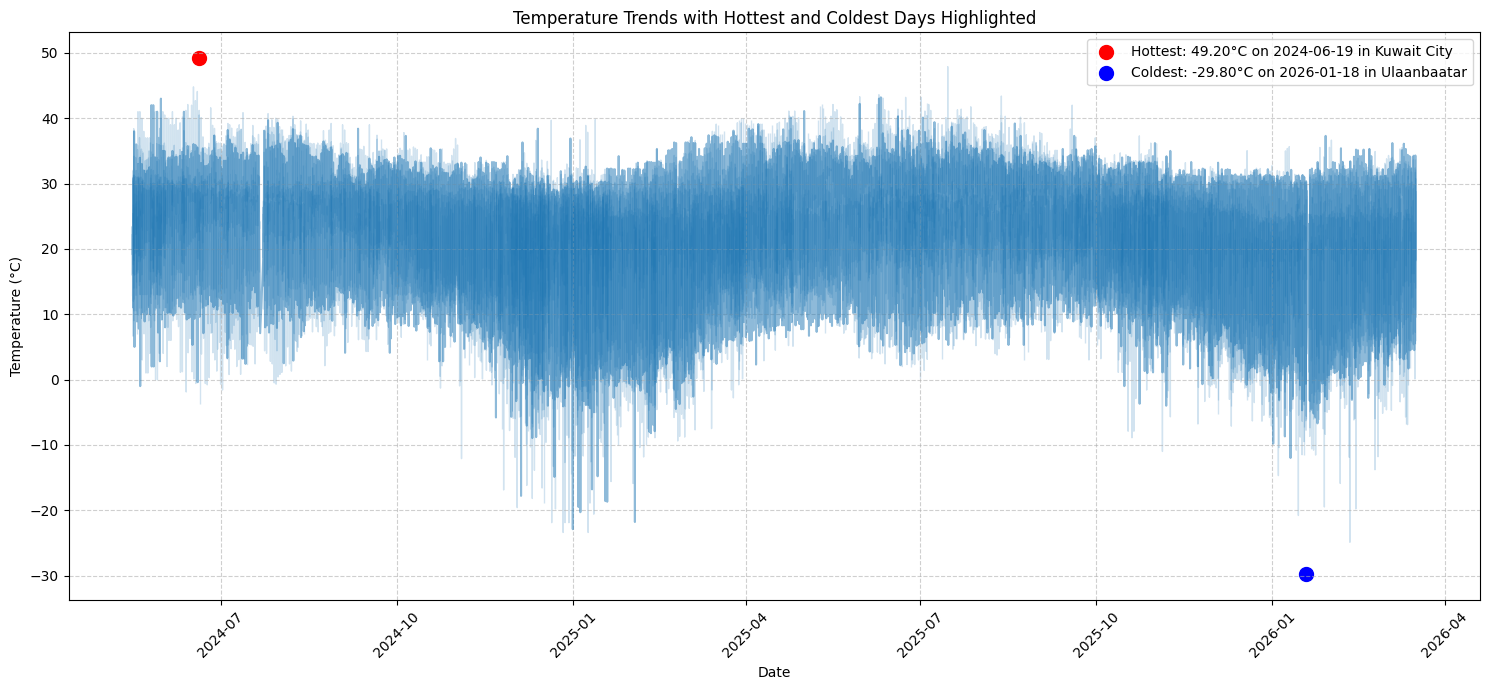

In [ ]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

hottest_day = df.loc[df['temperature_celsius'].idxmax()]
coldest_day = df.loc[df['temperature_celsius'].idxmin()]

print("Hottest Day in the dataset:")
print(f"Date: {hottest_day['last_updated'].date()}")
print(f"Location: {hottest_day['location_name']}, {hottest_day['country']}")
print(f"Temperature: {hottest_day['temperature_celsius']:.2f} °C\n")

print("Coldest Day in the dataset:")
print(f"Date: {coldest_day['last_updated'].date()}")
print(f"Location: {coldest_day['location_name']}, {coldest_day['country']}")
print(f"Temperature: {coldest_day['temperature_celsius']:.2f} °C\n")

# Plotting the hottest and coldest days
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='last_updated', y='temperature_celsius', data=df, alpha=0.5)
plt.scatter(hottest_day['last_updated'], hottest_day['temperature_celsius'], color='red', s=100, label=f'Hottest: {hottest_day['temperature_celsius']:.2f}°C on {hottest_day['last_updated'].date()} in {hottest_day['location_name']}')
plt.scatter(coldest_day['last_updated'], coldest_day['temperature_celsius'], color='blue', s=100, label=f'Coldest: {coldest_day['temperature_celsius']:.2f}°C on {coldest_day['last_updated'].date()} in {coldest_day['location_name']}')

plt.title('Temperature Trends with Hottest and Coldest Days Highlighted')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top-5 Hottest and coldest countries

In [ ]:
temperature_by_country = df.groupby('country')['temperature_celsius'].agg(['mean', 'min', 'max'])

# Sort by mean temperature for better visualization
temperature_by_country_sorted = temperature_by_country.sort_values(by='mean', ascending=False)

print("\nTemperature Statistics by Country (Sorted by Average Temperature):")
print(temperature_by_country_sorted.head()) # Display top 5
print(temperature_by_country_sorted.tail()) # Display bottom 5


Temperature Statistics by Country (Sorted by Average Temperature):
                           mean   min   max
country                                    
Saudi Arabien         45.000000  45.0  45.0
Marrocos              40.300000  40.3  40.3
Turkménistan          37.800000  37.8  37.8
Турция                34.000000  34.0  34.0
United Arab Emirates  32.464768  18.0  46.4
                mean   min   max
country                         
Norway      8.091128 -19.6  26.2
Kazakhstan  8.029730 -25.7  35.0
Iceland     5.701504  -7.7  17.2
Canada      4.995940 -25.0  29.2
Mongolia    3.498198 -29.8  34.3


top 10 hotest and coldest countries

/tmp/ipykernel_16275/3522132801.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean', y=top_10_hottest.index, data=top_10_hottest, palette='hot')
/tmp/ipykernel_16275/3522132801.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean', y=top_10_coldest.index, data=top_10_coldest, palette='cool')


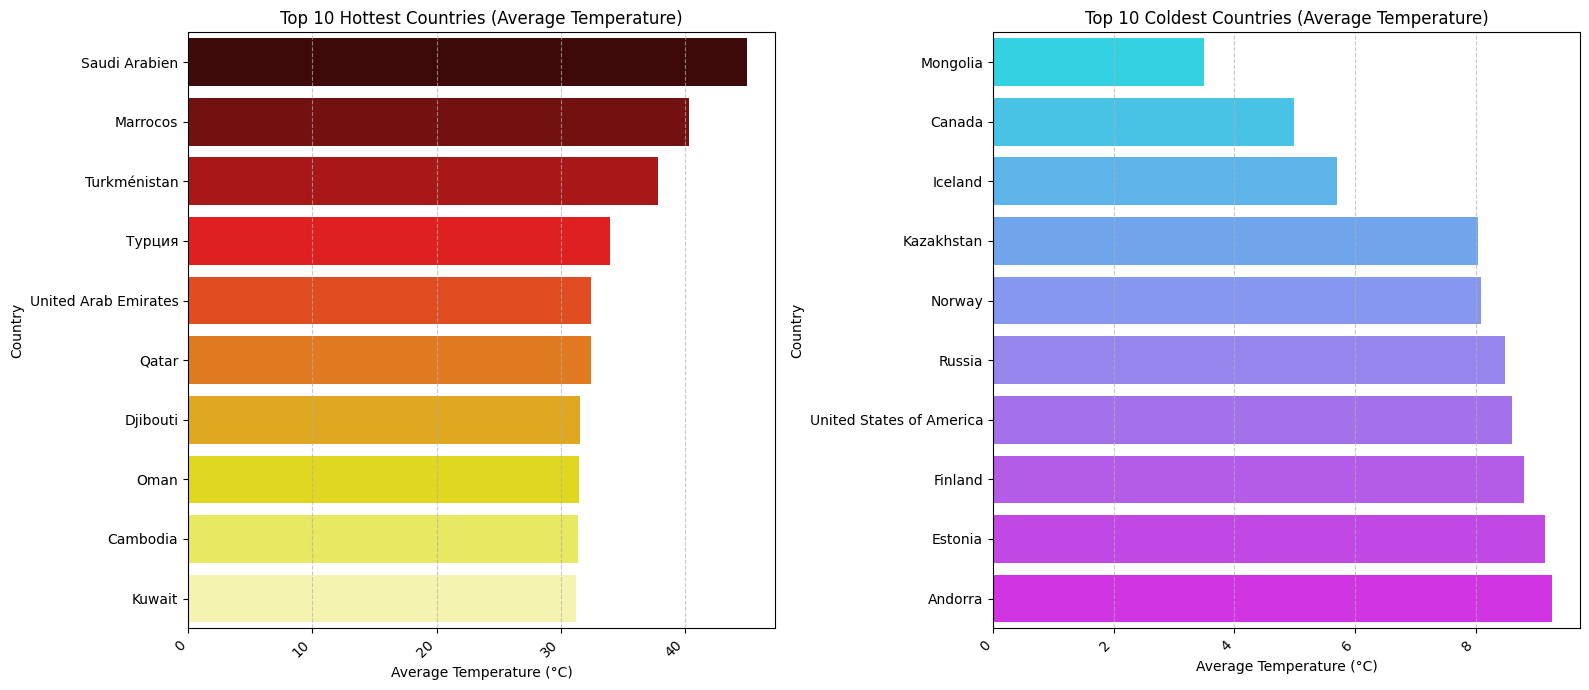

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10 hottest countries
top_10_hottest = temperature_by_country_sorted.head(10)

# Get top 10 coldest countries (reverse the order for plotting coldest at the top of its plot)
top_10_coldest = temperature_by_country_sorted.tail(10).sort_values(by='mean', ascending=True)

plt.figure(figsize=(16, 7))

# Plot for Hottest Countries
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='mean', y=top_10_hottest.index, data=top_10_hottest, palette='hot')
plt.title('Top 10 Hottest Countries (Average Temperature)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot for Coldest Countries
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='mean', y=top_10_coldest.index, data=top_10_coldest, palette='cool')
plt.title('Top 10 Coldest Countries (Average Temperature)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
european_countries = [
    'United Kingdom',
    'France',
    'Germany',
    'Spain',
    'Italy',
    'Netherlands',
    'Belgium',
    'Sweden',
    'Poland',
    'Austria',
    'Portugal',
    'Ireland'
]

# Filter the DataFrame for the selected European countries
eu_df = df[df['country'].isin(european_countries)].copy()

# Ensure 'last_updated' is in datetime format (if not already converted)
eu_df['last_updated'] = pd.to_datetime(eu_df['last_updated'])

print(f"Data for selected European countries (first 5 rows):\n{eu_df.head()}\n")

Data for selected European countries (first 5 rows):
    country location_name  latitude  longitude         timezone  \
9   Austria        Vienna     48.20      16.37    Europe/Vienna   
16  Belgium      Brussels     50.83       4.33  Europe/Brussels   
60   France         Paris     48.87       2.33     Europe/Paris   
64  Germany        Berlin     52.52      13.40    Europe/Berlin   
81  Ireland        Dublin     53.33      -6.25    Europe/Dublin   

    last_updated_epoch        last_updated  temperature_celsius  \
9           1715849100 2024-05-16 10:45:00                 16.0   
16          1715849100 2024-05-16 10:45:00                 15.0   
60          1715849100 2024-05-16 10:45:00                 15.0   
64          1715849100 2024-05-16 10:45:00                 22.0   
81          1715849100 2024-05-16 09:45:00                 14.0   

    temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
9                     60.8  Partly cloudy  ...                3.7   
16 

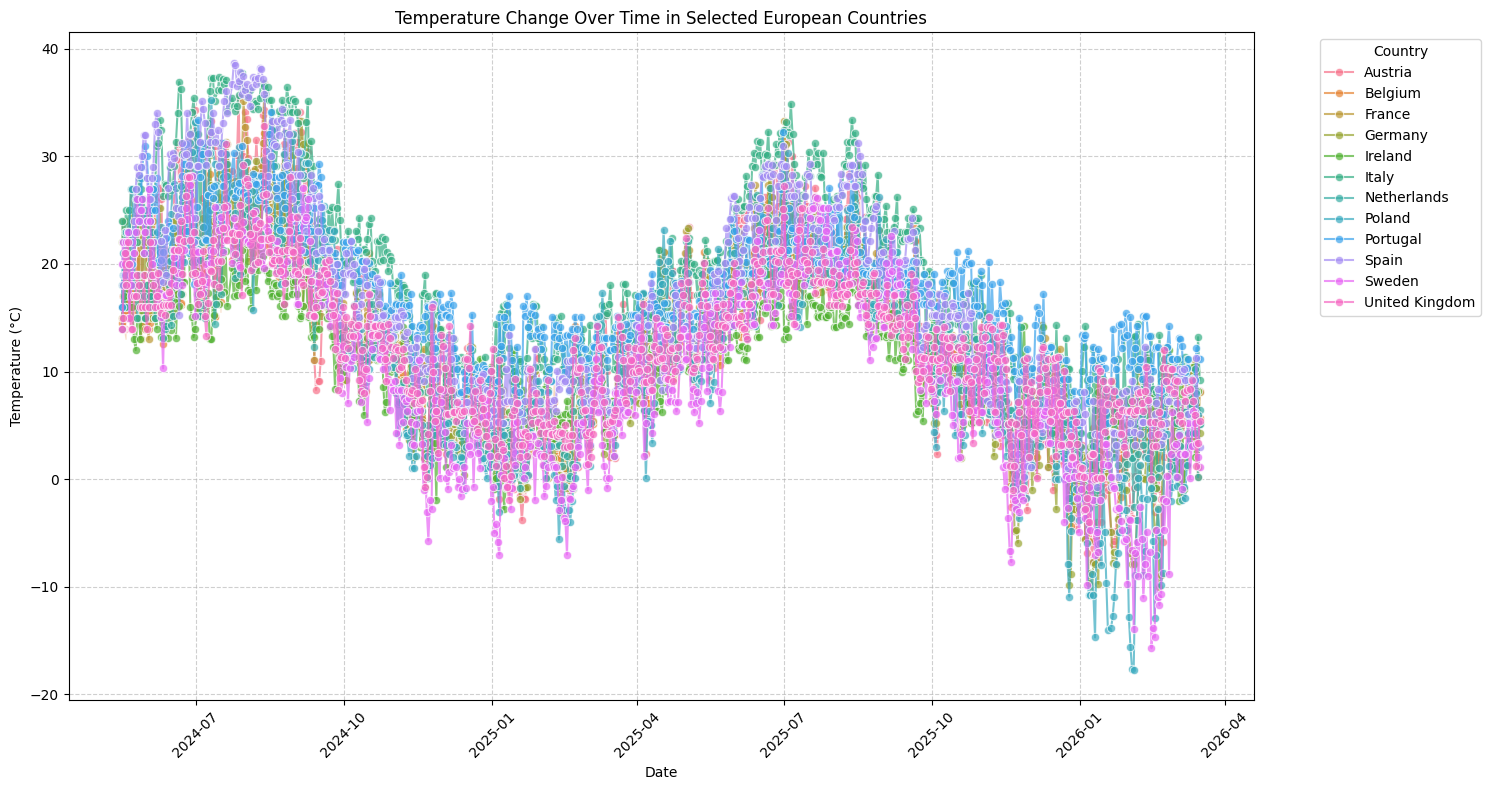

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.lineplot(data=eu_df, x='last_updated', y='temperature_celsius', hue='country', marker='o', alpha=0.7)

plt.title('Temperature Change Over Time in Selected European Countries')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

air_quality_columns = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

air_quality_by_country = df.groupby('country')[air_quality_columns].mean()

print("\nAverage Air Quality Metrics by Country (Head):")
print(air_quality_by_country.head())

print("\nAverage Air Quality Metrics by Country (Tail):")
print(air_quality_by_country.tail())

In [ ]:
# Calculate average wind speed for each country
wind_by_country = df.groupby('country')['wind_kph'].mean().sort_values(ascending=False)

# Get the top 10 windy countries
top_10_windy_countries = wind_by_country.head(10).index.tolist()

print("Top 10 Windy Countries (Average Wind Speed in kph):")
print(wind_by_country.head(10))

# Filter the original DataFrame for these top 10 countries
top_windy_df = df[df['country'].isin(top_10_windy_countries)].copy()

# Ensure 'last_updated' is in datetime format
top_windy_df['last_updated'] = pd.to_datetime(top_windy_df['last_updated'])

Top 10 Windy Countries (Average Wind Speed in kph):
country
Libya                               31.700000
Polônia                             29.500000
Somalia                             27.720752
Saint-Vincent-et-les-Grenadines     27.000000
Saint Vincent and the Grenadines    26.014910
Saint Kitts and Nevis               25.716842
Komoren                             24.800000
New Zealand                         24.786186
Saudi Arabien                       24.500000
Antigua and Barbuda                 24.495023
Name: wind_kph, dtype: float64


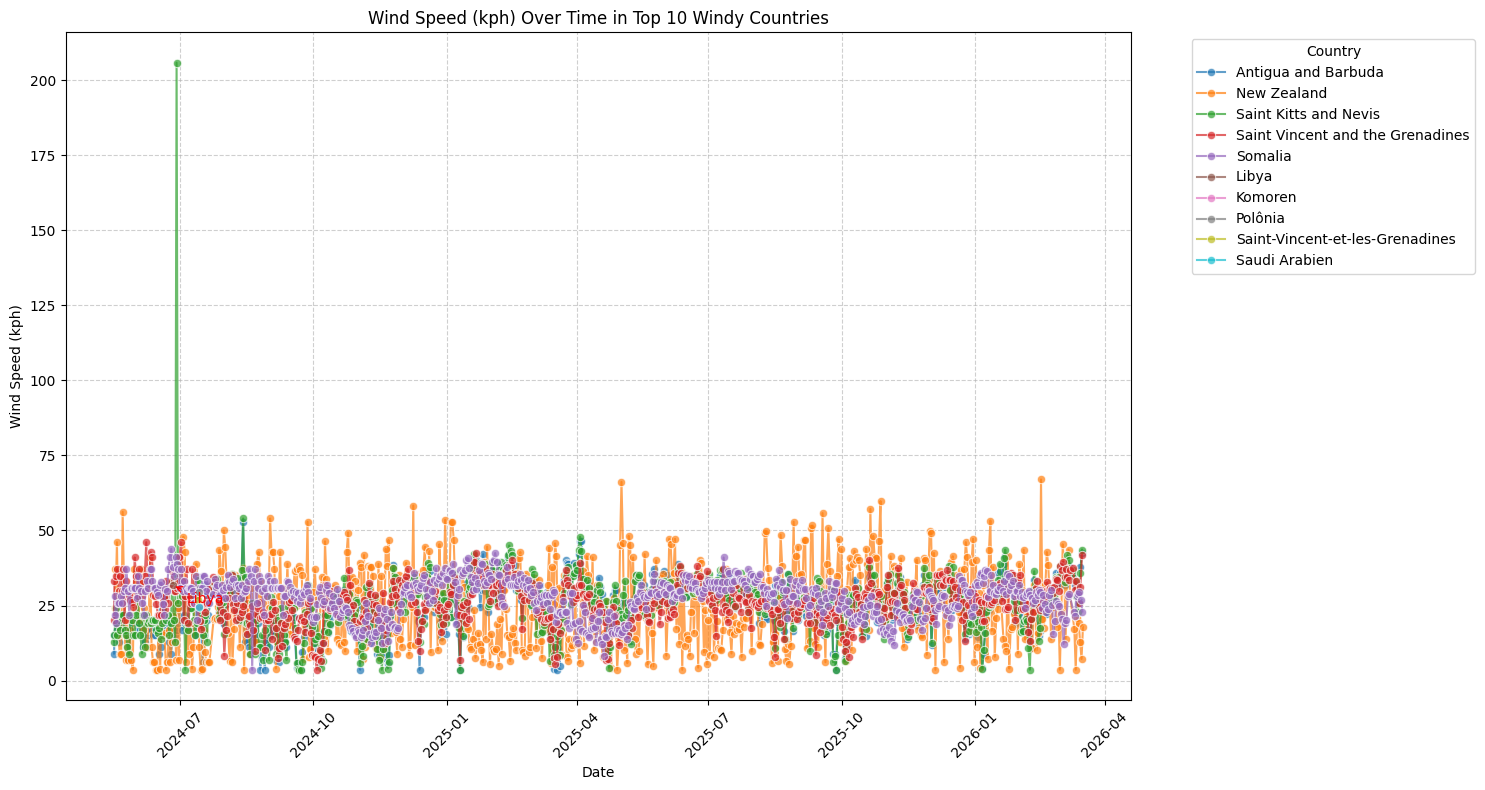

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.lineplot(data=top_windy_df, x='last_updated', y='wind_kph', hue='country', marker='o', alpha=0.7)

plt.title('Wind Speed (kph) Over Time in Top 10 Windy Countries')
plt.xlabel('Date')
plt.ylabel('Wind Speed (kph)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

# Identify the top windy country and its data point
top_country_name = wind_by_country.index[0] # Get the name of the top windy country
top_country_data = top_windy_df[top_windy_df['country'] == top_country_name]

# Find the last data point for the top country to place the label
if not top_country_data.empty:
    last_point = top_country_data.iloc[-1]
    plt.annotate(top_country_name,
                 (last_point['last_updated'], last_point['wind_kph']),
                 textcoords="offset points",
                 xytext=(10,-10),
                 ha='left',
                 va='center',
                 color='red',
                 fontsize=10,
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Ensure 'european_countries' list is available
if 'european_countries' not in locals():
    print("Error: 'european_countries' list not found. Please define it first.")
else:
    # Filter DataFrame to include only European countries
    eu_df_for_wind = df[df['country'].isin(european_countries)].copy()

    # Calculate average wind speed for European countries
    eu_wind_by_country = eu_df_for_wind.groupby('country')['wind_kph'].mean().sort_values(ascending=False)

    # Get the top N windy European countries (e.g., top 10 from Europe)
    # Adjust N as needed, or take all if less than 10
    top_windy_european_countries = eu_wind_by_country.head(10).index.tolist()

    # Calculate average temperature for these top windy European countries
    # Ensure 'temperature_by_country_sorted' is derived from European data if possible, or filtered.
    # For simplicity, we'll re-calculate mean temp for these specific countries from eu_df_for_wind
    avg_temp_top_windy_eu = eu_df_for_wind[eu_df_for_wind['country'].isin(top_windy_european_countries)].groupby('country')['temperature_celsius'].mean()
    avg_wind_top_windy_eu = eu_wind_by_country[eu_wind_by_country.index.isin(top_windy_european_countries)]

    # Combine into a single DataFrame for plotting
    comparison_df = pd.DataFrame({
        'Average Temperature (C)': avg_temp_top_windy_eu,
        'Average Wind Speed (kph)': avg_wind_top_windy_eu
    }).sort_values(by='Average Wind Speed (kph)', ascending=False)

    if not comparison_df.empty:
        print("Comparison of Average Temperature and Wind Speed for Top Windy European Countries:")
        print(comparison_df)
    else:
        print("No data available for top windy European countries based on current filtering.")

Comparison of Average Temperature and Wind Speed for Top Windy European Countries:
                Average Temperature (C)  Average Wind Speed (kph)
country                                                          
Belgium                       12.647068                 16.840729
Netherlands                   12.520540                 16.476312
Ireland                       11.096241                 16.388571
Portugal                      17.192492                 14.915165
Sweden                         9.895495                 14.487237
Germany                       12.032684                 14.328036
United Kingdom                12.456391                 14.210677
Poland                        11.728293                 13.763473
Austria                       12.897001                 12.869865
France                        13.433634                 12.635135


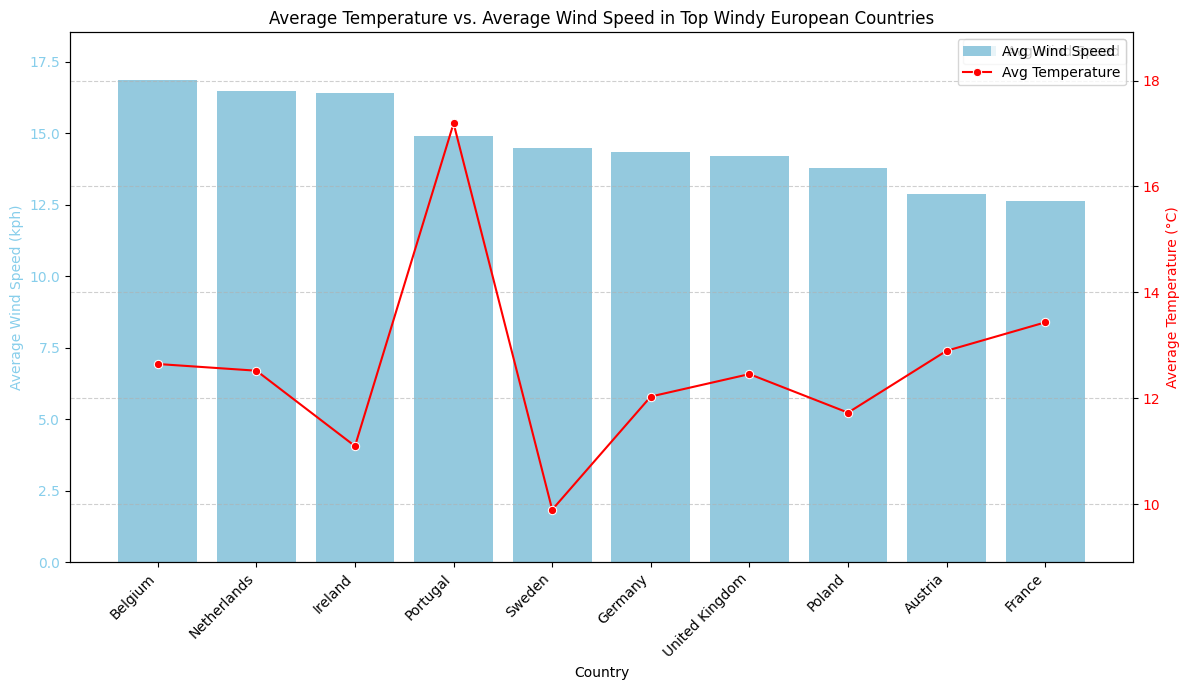

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only proceed with plotting if comparison_df is not empty
if not comparison_df.empty:
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Plot Average Wind Speed
    sns.barplot(x=comparison_df.index, y='Average Wind Speed (kph)', data=comparison_df, ax=ax1, color='skyblue', label='Avg Wind Speed')
    ax1.set_xlabel('Country')
    ax1.set_ylabel('Average Wind Speed (kph)', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')
    ax1.set_ylim(0, comparison_df['Average Wind Speed (kph)'].max() * 1.1)
    plt.xticks(rotation=45, ha='right')

    # Create a second y-axis for Average Temperature
    ax2 = ax1.twinx()
    sns.lineplot(x=comparison_df.index, y='Average Temperature (C)', data=comparison_df, ax=ax2, color='red', marker='o', label='Avg Temperature')
    ax2.set_ylabel('Average Temperature (°C)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(comparison_df['Average Temperature (C)'].min() * 0.9, comparison_df['Average Temperature (C)'].max() * 1.1)

    # Combine legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')

    plt.title('Average Temperature vs. Average Wind Speed in Top Windy European Countries')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for top windy European countries.")

In [ ]:
# Ensure european_countries list is available (it is from previous steps)

# Filter DataFrame to include only European countries
all_eu_df = df[df['country'].isin(european_countries)].copy()

# Calculate average wind speed for all European countries
avg_wind_all_eu = all_eu_df.groupby('country')['wind_kph'].mean().sort_values(ascending=False)

# Calculate average temperature for all European countries
avg_temp_all_eu = all_eu_df.groupby('country')['temperature_celsius'].mean()

# Combine into a single DataFrame for plotting
comparison_df_all_eu = pd.DataFrame({
    'Average Temperature (C)': avg_temp_all_eu,
    'Average Wind Speed (kph)': avg_wind_all_eu
}).sort_values(by='Average Wind Speed (kph)', ascending=False)

if not comparison_df_all_eu.empty:
    print("Comparison of Average Temperature and Wind Speed for All Selected European Countries:")
    print(comparison_df_all_eu)
else:
    print("No data available for the selected European countries to compare.")

Comparison of Average Temperature and Wind Speed for All Selected European Countries:
                Average Temperature (C)  Average Wind Speed (kph)
country                                                          
Belgium                       12.647068                 16.840729
Netherlands                   12.520540                 16.476312
Ireland                       11.096241                 16.388571
Portugal                      17.192492                 14.915165
Sweden                         9.895495                 14.487237
Germany                       12.032684                 14.328036
United Kingdom                12.456391                 14.210677
Poland                        11.728293                 13.763473
Austria                       12.897001                 12.869865
France                        13.433634                 12.635135
Spain                         16.031784                 11.051574
Italy                         18.971364                 

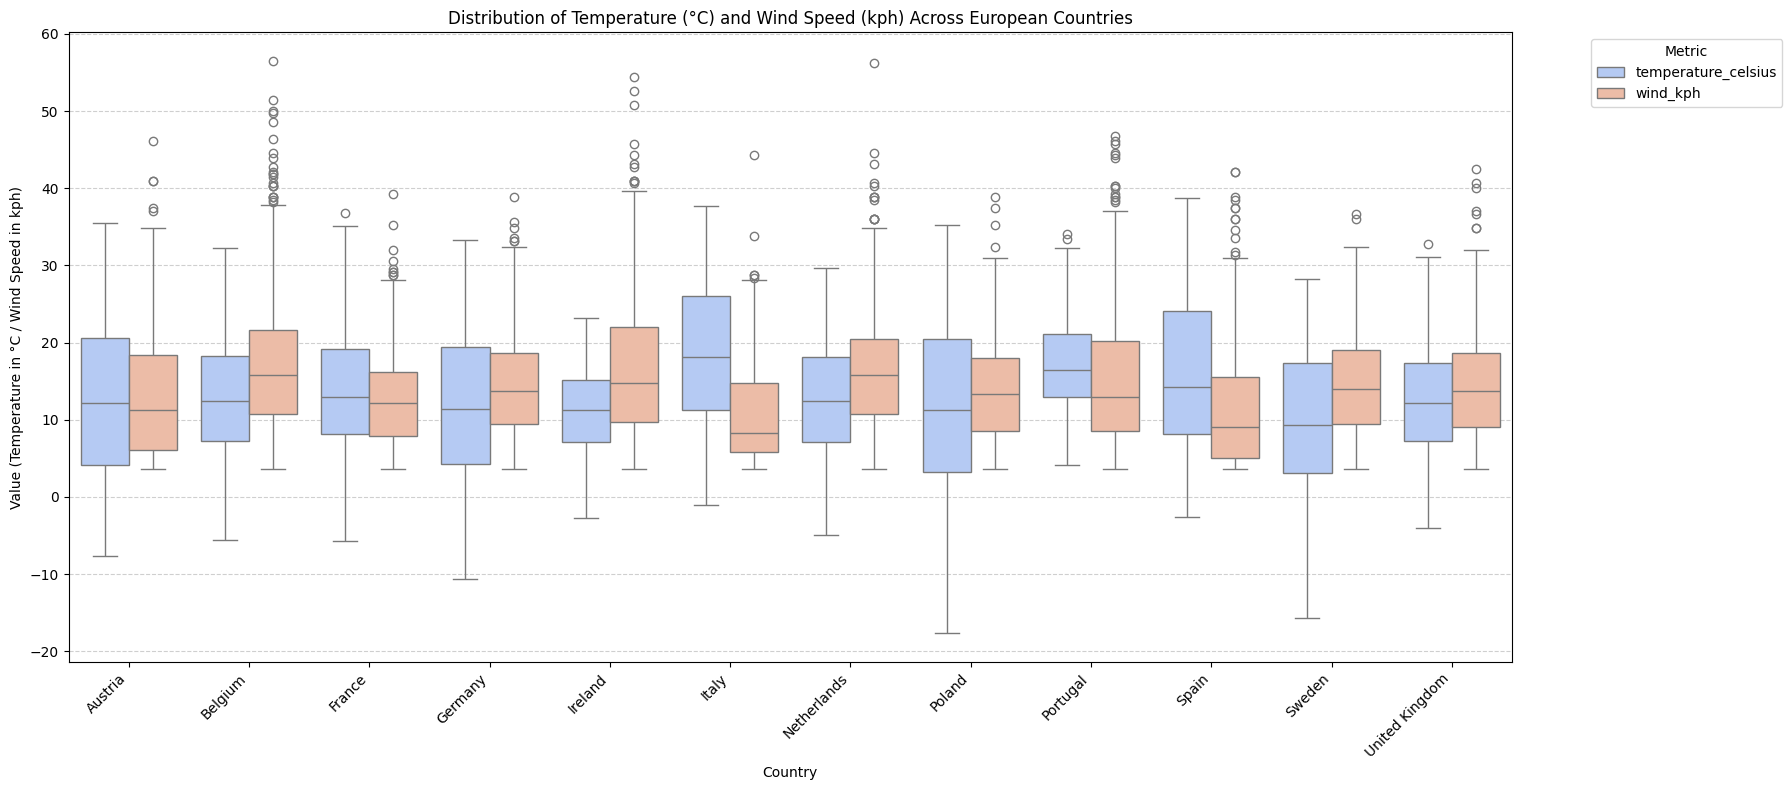

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Only proceed with plotting if all_eu_df is not empty
if not all_eu_df.empty:
    # Melt the DataFrame to combine temperature and wind speed into a single 'Value' column
    # with a 'Metric' column to distinguish them.
    df_melted = all_eu_df.melt(id_vars=['country'], value_vars=['temperature_celsius', 'wind_kph'],
                               var_name='Metric', value_name='Value')

    plt.figure(figsize=(18, 8)) # Adjusted figure size for better readability with grouped boxplots
    sns.boxplot(x='country', y='Value', hue='Metric', data=df_melted, palette='coolwarm')
    plt.title('Distribution of Temperature (°C) and Wind Speed (kph) Across European Countries')
    plt.xlabel('Country')
    plt.ylabel('Value (Temperature in °C / Wind Speed in kph)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for the selected European countries to plot.")

Top 5 Coldest European Countries (Average Temperature):
country
Sweden             9.895495
Ireland           11.096241
Poland            11.728293
Germany           12.032684
United Kingdom    12.456391
Name: temperature_celsius, dtype: float64

Data for the Top 5 Coldest European Countries (first 5 rows):
            country location_name  latitude  longitude          timezone  \
64          Germany        Berlin     52.52      13.40     Europe/Berlin   
81          Ireland        Dublin     53.33      -6.25     Europe/Dublin   
139          Poland        Warsaw     52.25      21.00     Europe/Warsaw   
168          Sweden     Stockholm     59.33      18.05  Europe/Stockholm   
185  United Kingdom        London     51.52      -0.11     Europe/London   

     last_updated_epoch        last_updated  temperature_celsius  \
64           1715849100 2024-05-16 10:45:00                 22.0   
81           1715849100 2024-05-16 09:45:00                 14.0   
139          1715849100 2024-0

/tmp/ipykernel_16275/1868940174.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coldest_eu_countries.index, y=coldest_eu_countries.values, palette='cool')


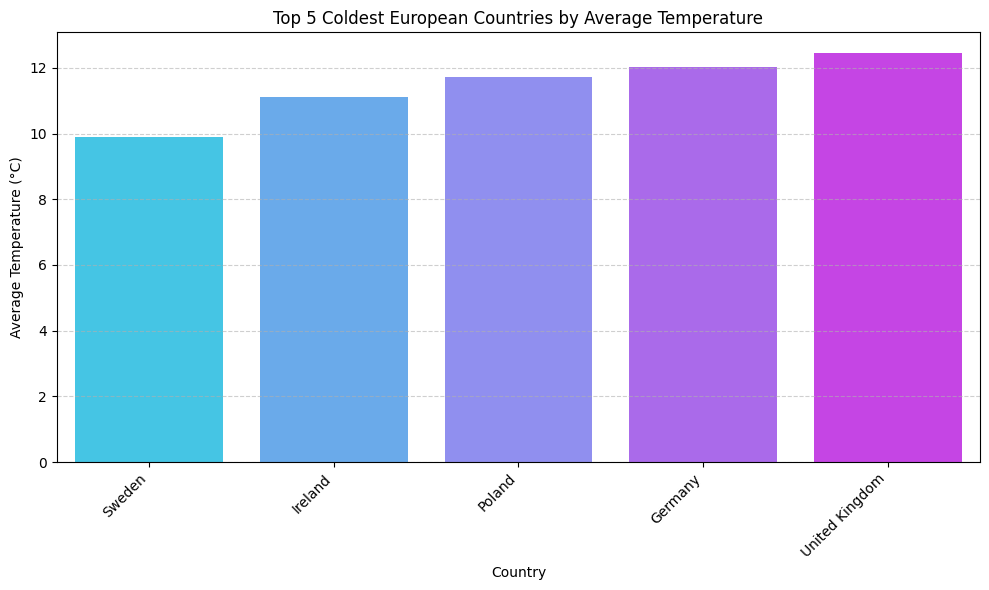

In [ ]:
# Calculate average temperature for all European countries (if not already done)
if 'avg_temp_all_eu' not in locals():
    all_eu_df = df[df['country'].isin(european_countries)].copy()
    avg_temp_all_eu = all_eu_df.groupby('country')['temperature_celsius'].mean()

# Get the top 5 coldest European countries
coldest_eu_countries = avg_temp_all_eu.sort_values(ascending=True).head(5)

print("Top 5 Coldest European Countries (Average Temperature):")
print(coldest_eu_countries)

# Filter the European DataFrame to include only these 5 countries
filtered_coldest_eu_df = all_eu_df[all_eu_df['country'].isin(coldest_eu_countries.index)].copy()

print("\nData for the Top 5 Coldest European Countries (first 5 rows):")
print(filtered_coldest_eu_df.head())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=coldest_eu_countries.index, y=coldest_eu_countries.values, palette='cool')
plt.title('Top 5 Coldest European Countries by Average Temperature')
plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Air Quality

In [ ]:
# Ensure air_quality_by_country is available
if 'air_quality_by_country' not in locals():
    air_quality_columns = [
        'air_quality_Carbon_Monoxide',
        'air_quality_Ozone',
        'air_quality_Nitrogen_dioxide',
        'air_quality_Sulphur_dioxide',
        'air_quality_PM2.5',
        'air_quality_PM10',
        'air_quality_us-epa-index',
        'air_quality_gb-defra-index'
    ]
    air_quality_by_country = df.groupby('country')[air_quality_columns].mean()

# Sort by PM2.5 to find the most polluted countries
top_10_polluted = air_quality_by_country.sort_values(by='air_quality_PM2.5', ascending=False).head(10)

print("\nTop 10 Most Polluted Countries (Average PM2.5):")
print(top_10_polluted[['air_quality_PM2.5']])


Top 10 Most Polluted Countries (Average PM2.5):
              air_quality_PM2.5
country                        
Chile                155.485173
Saudi Arabia         138.322958
China                136.199902
India                112.992835
Kuwait                93.370090
Indonesia             85.732846
Bangladesh            72.813986
Südkorea              70.200000
Mauritania            67.832327
Bahrain               65.951972


/tmp/ipykernel_16275/3429828199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='air_quality_PM2.5', y=top_10_polluted.index, data=top_10_polluted, palette='Reds_d')


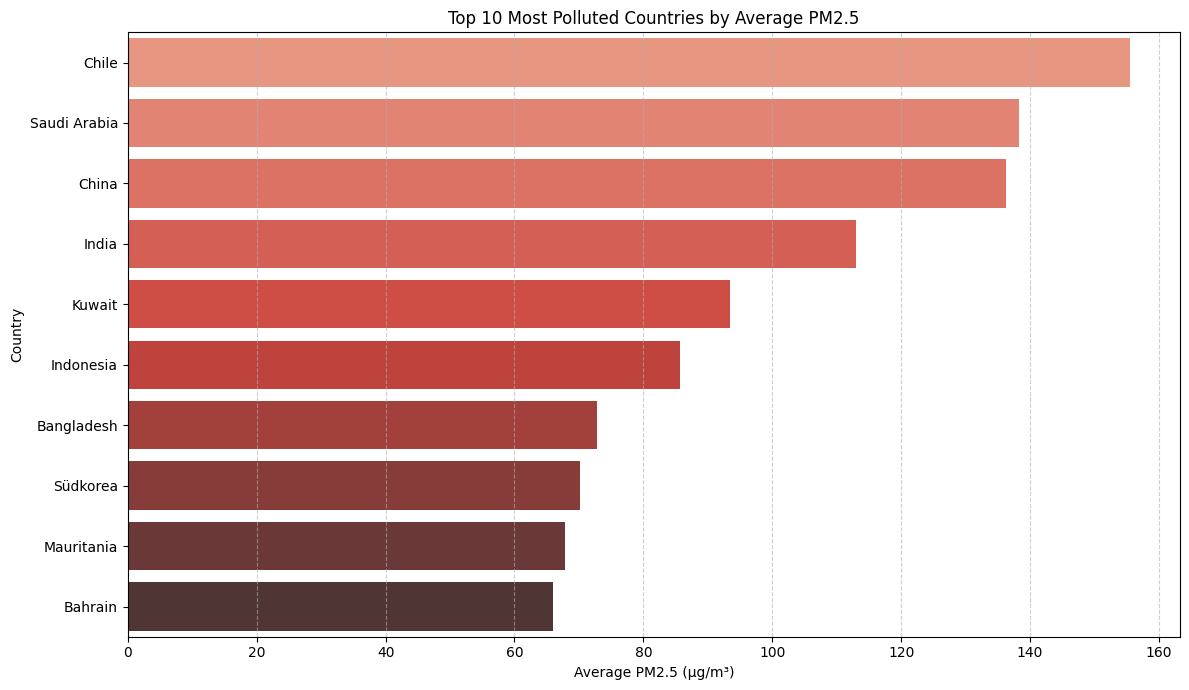

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='air_quality_PM2.5', y=top_10_polluted.index, data=top_10_polluted, palette='Reds_d')
plt.title('Top 10 Most Polluted Countries by Average PM2.5')
plt.xlabel('Average PM2.5 (µg/m³)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Ensure air_quality_by_country is available (if not, re-calculate)
if 'air_quality_by_country' not in locals():
    air_quality_columns = [
        'air_quality_Carbon_Monoxide',
        'air_quality_Ozone',
        'air_quality_Nitrogen_dioxide',
        'air_quality_Sulphur_dioxide',
        'air_quality_PM2.5',
        'air_quality_PM10',
        'air_quality_us-epa-index',
        'air_quality_gb-defra-index'
    ]
    air_quality_by_country = df.groupby('country')[air_quality_columns].mean()

# Filter air quality data for European countries only
eu_air_quality = air_quality_by_country[air_quality_by_country.index.isin(european_countries)]

# Sort by PM2.5 to find the most polluted European countries
top_10_polluted_eu = eu_air_quality.sort_values(by='air_quality_PM2.5', ascending=False).head(10)

print("\nTop 10 Most Polluted European Countries (All Air Quality Metrics):")
print(top_10_polluted_eu[['air_quality_Carbon_Monoxide',
        'air_quality_Ozone',
        'air_quality_Nitrogen_dioxide',
        'air_quality_Sulphur_dioxide',
        'air_quality_PM2.5',
        'air_quality_PM10',
        'air_quality_us-epa-index',
        'air_quality_gb-defra-index']])


Top 10 Most Polluted European Countries (All Air Quality Metrics):
                air_quality_Carbon_Monoxide  air_quality_Ozone  \
country                                                          
Poland                           366.269611          52.653293   
France                           413.063664          44.330781   
Austria                          347.701499          54.571514   
Belgium                          326.258637          50.462520   
Netherlands                      353.497151          42.685907   
Italy                            301.386957          58.876162   
Portugal                         244.037613          58.571471   
Spain                            277.978111          44.936132   
Germany                          338.421814          51.986507   
United Kingdom                   302.585414          50.436241   

                air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  \
country                                                       

/tmp/ipykernel_16275/2171104612.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='air_quality_Carbon_Monoxide', data=top_10_polluted_eu_reset, palette='coolwarm')


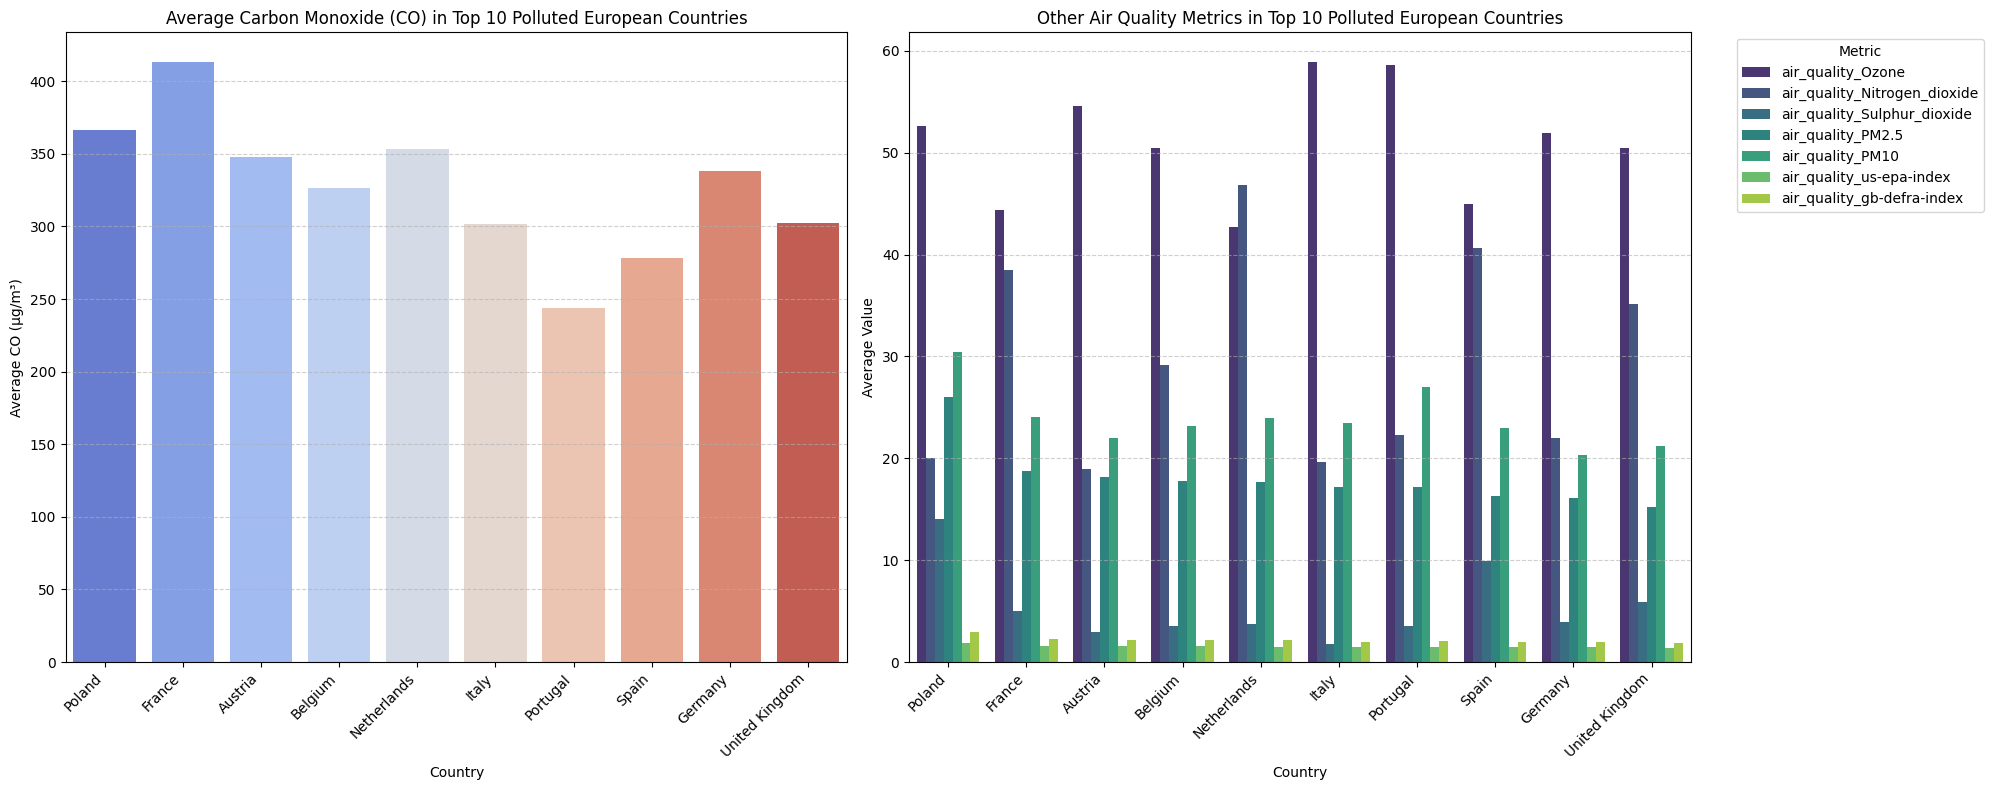

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for melting

# List of all air quality metrics
all_aq_metrics = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

plt.figure(figsize=(20, 8))

# --- Plot 1: Carbon Monoxide (CO) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
# Reset index to make 'country' a column for plotting if it's the index
top_10_polluted_eu_reset = top_10_polluted_eu.reset_index()
sns.barplot(x='country', y='air_quality_Carbon_Monoxide', data=top_10_polluted_eu_reset, palette='coolwarm')
plt.title('Average Carbon Monoxide (CO) in Top 10 Polluted European Countries')
plt.xlabel('Country')
plt.ylabel('Average CO (µg/m³)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot 2: Other Air Quality Parameters ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot

# Filter out CO from the list of metrics for the second plot
other_aq_metrics = [metric for metric in all_aq_metrics if metric != 'air_quality_Carbon_Monoxide']

# Melt the DataFrame for other air quality metrics, using the reset index DataFrame
df_melted_other_aq = top_10_polluted_eu_reset[other_aq_metrics + ['country']].melt(id_vars='country',
                                                                               var_name='Air Quality Metric',
                                                                               value_name='Average Value')

sns.barplot(x='country', y='Average Value', hue='Air Quality Metric', data=df_melted_other_aq, palette='viridis')
plt.title('Other Air Quality Metrics in Top 10 Polluted European Countries')
plt.xlabel('Country')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

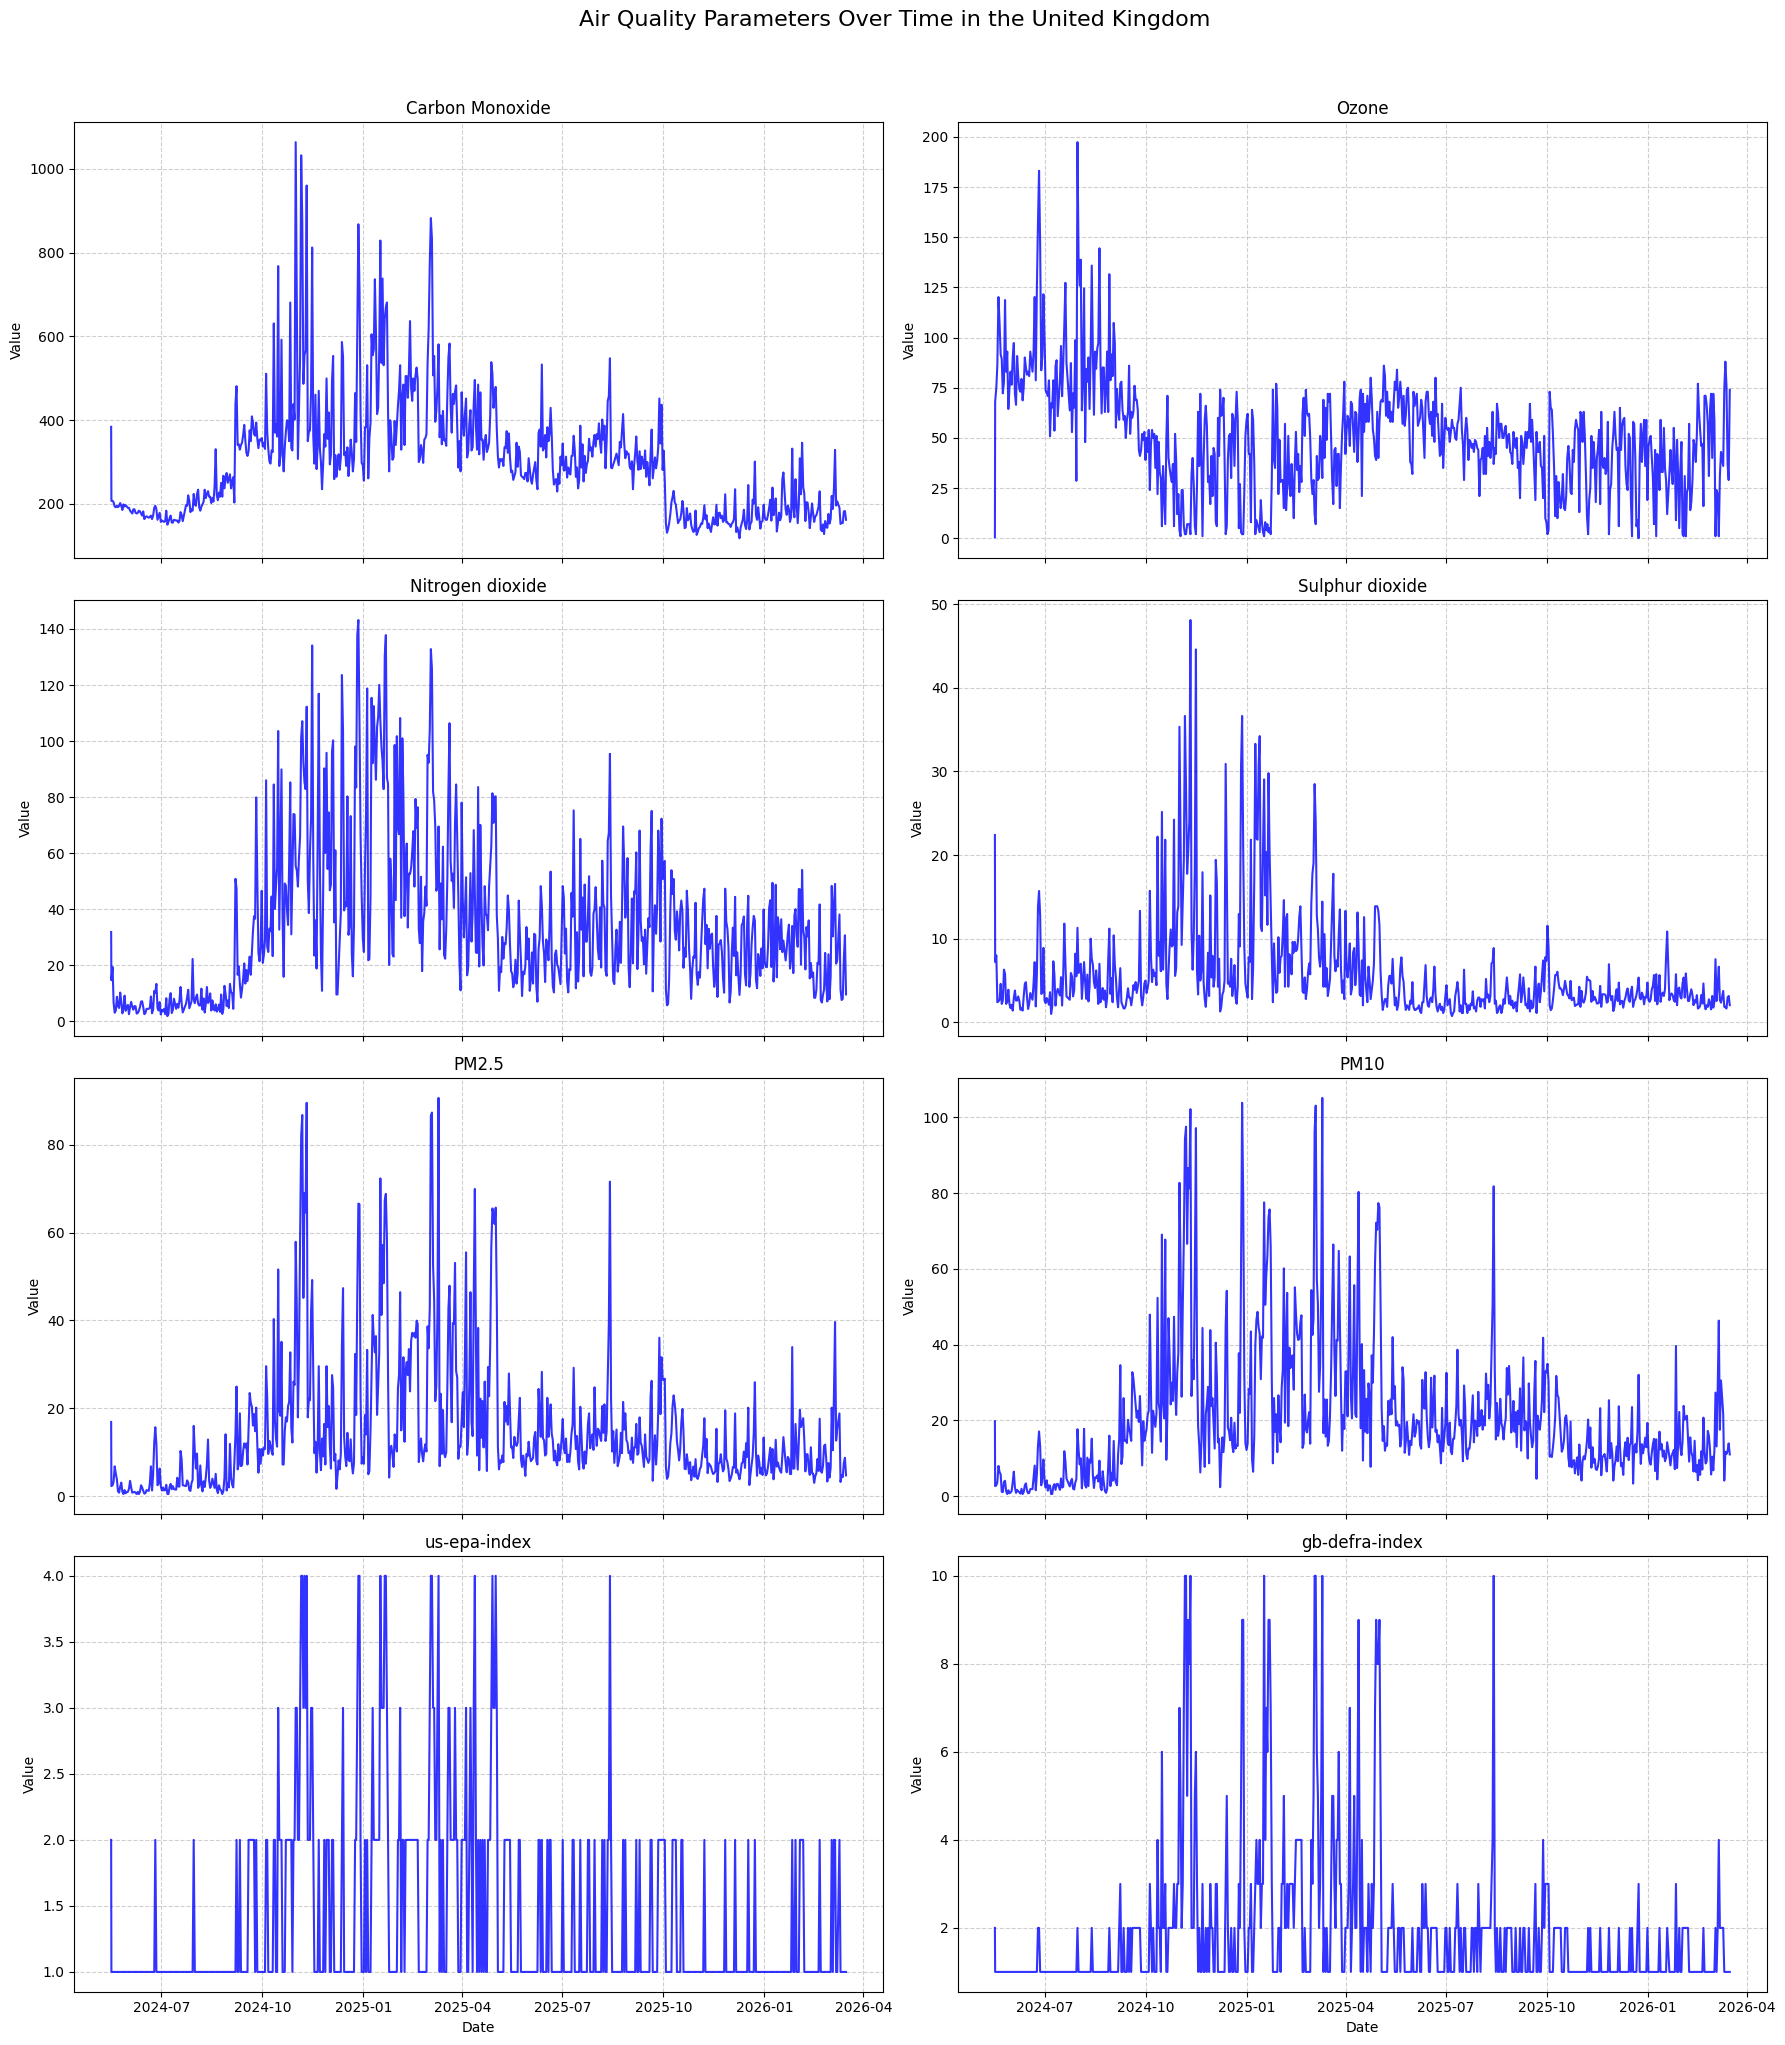

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter data for the United Kingdom
uk_df = df[df['country'] == 'United Kingdom'].copy()

# Ensure 'last_updated' is in datetime format
uk_df['last_updated'] = pd.to_datetime(uk_df['last_updated'])

# List of air quality columns (excluding index columns if they were part of previous analysis)
air_quality_columns = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

# Prepare for plotting: Melt the DataFrame for easy plotting of multiple metrics over time
uk_air_quality_melted = uk_df.melt(id_vars=['last_updated'], value_vars=air_quality_columns,
                                   var_name='Air Quality Metric', value_name='Value')

# Create a figure with subplots for each air quality metric
# Determine number of rows and columns for subplots dynamically
n_metrics = len(air_quality_columns)
n_cols = 2 # Or adjust based on preference
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5), sharex=True)
axes = axes.flatten() # Flatten the array of axes for easy iteration

plt.suptitle('Air Quality Parameters Over Time in the United Kingdom', y=1.02, fontsize=16)

for i, metric in enumerate(air_quality_columns):
    sns.lineplot(x='last_updated', y='Value', data=uk_air_quality_melted[uk_air_quality_melted['Air Quality Metric'] == metric],
                 ax=axes[i], color='blue', alpha=0.8)
    axes[i].set_title(metric.replace('air_quality_', '').replace('_', ' '))
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Weather/Seasonal


Most Frequent Weather Condition per European Country:
            country condition_text  count
18          Austria  partly cloudy    254
43          Belgium  partly cloudy    440
71           France          sunny    192
95          Germany          sunny    220
108         Ireland  partly cloudy    457
125           Italy          sunny    348
142     Netherlands  partly cloudy    258
162          Poland  partly cloudy    253
181        Portugal  partly cloudy    292
198           Spain          sunny    344
216          Sweden  partly cloudy    267
233  United Kingdom  partly cloudy    296

Top 3 Weather Conditions per European Country:
           country      condition_text  count
0          Austria       partly cloudy    254
1          Austria               sunny    223
2          Austria          light rain     47
3          Belgium       partly cloudy    440
4          Belgium               sunny    256
5          Belgium            overcast    168
6           France           

/tmp/ipykernel_16275/3956409677.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_conditions = condition_counts.groupby('country').apply(get_top_n_conditions).reset_index(drop=True)


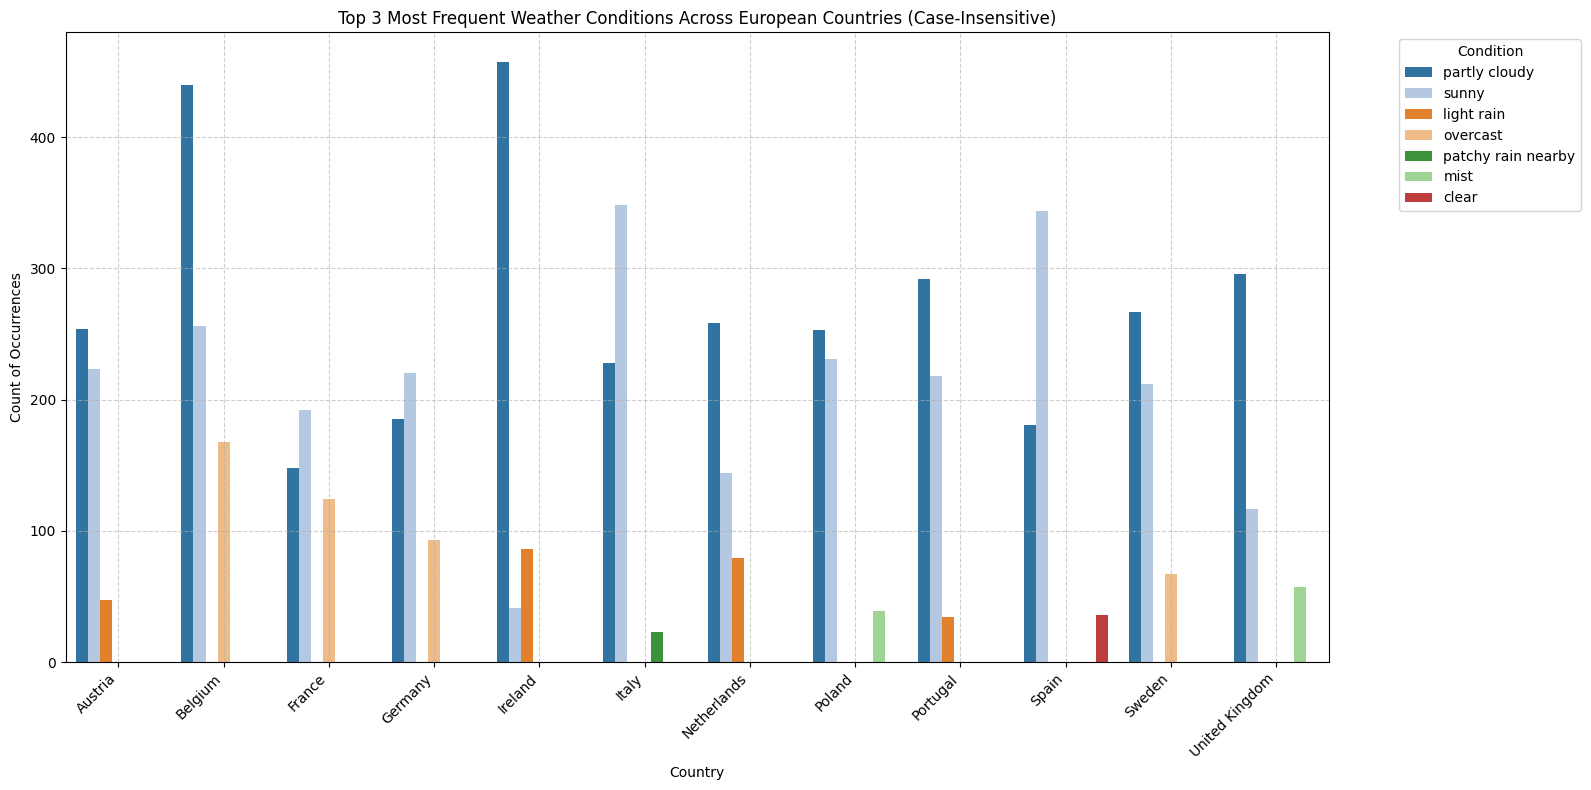

In [ ]:
# Ensure eu_df and european_countries are available
if 'eu_df' not in locals() or eu_df.empty:
    if 'european_countries' not in locals():
        european_countries = [
            'United Kingdom', 'France', 'Germany', 'Spain', 'Italy',
            'Netherlands', 'Belgium', 'Sweden', 'Poland', 'Austria',
            'Portugal', 'Ireland'
        ]
    eu_df = df[df['country'].isin(european_countries)].copy()

# Convert 'condition_text' to lowercase for case-insensitive grouping
eu_df['condition_text'] = eu_df['condition_text'].str.lower()

# Group by country and condition_text to count occurrences
condition_counts = eu_df.groupby(['country', 'condition_text']).size().reset_index(name='count')

# Find the most frequent condition for each country
idx = condition_counts.groupby('country')['count'].idxmax()
most_frequent_conditions = condition_counts.loc[idx]

print("\nMost Frequent Weather Condition per European Country:")
print(most_frequent_conditions)

# Optionally, get top N conditions per country for a more detailed view
def get_top_n_conditions(df_group, n=3):
    return df_group.sort_values(by='count', ascending=False).head(n)

top_n_conditions = condition_counts.groupby('country').apply(get_top_n_conditions).reset_index(drop=True)

print("\nTop 3 Weather Conditions per European Country:")
print(top_n_conditions)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.barplot(x='country', y='count', hue='condition_text', data=top_n_conditions, palette='tab20')
plt.title('Top 3 Most Frequent Weather Conditions Across European Countries (Case-Insensitive)')
plt.xlabel('Country')
plt.ylabel('Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Correlation between Wind Speed (kph) and Humidity (%) for European Countries (Sorted by strength):
country
Italy            -0.256774
Sweden           -0.217937
Austria          -0.187026
Poland           -0.174805
Germany          -0.161690
Ireland          -0.150708
United Kingdom   -0.147113
Spain             0.122631
Netherlands      -0.072743
France           -0.054758
Portugal         -0.041195
Belgium          -0.032494
Name: (wind_kph, humidity), dtype: float64


/tmp/ipykernel_16275/167255560.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_wh_sorted.index, y=correlation_wh_sorted.values, palette='coolwarm')


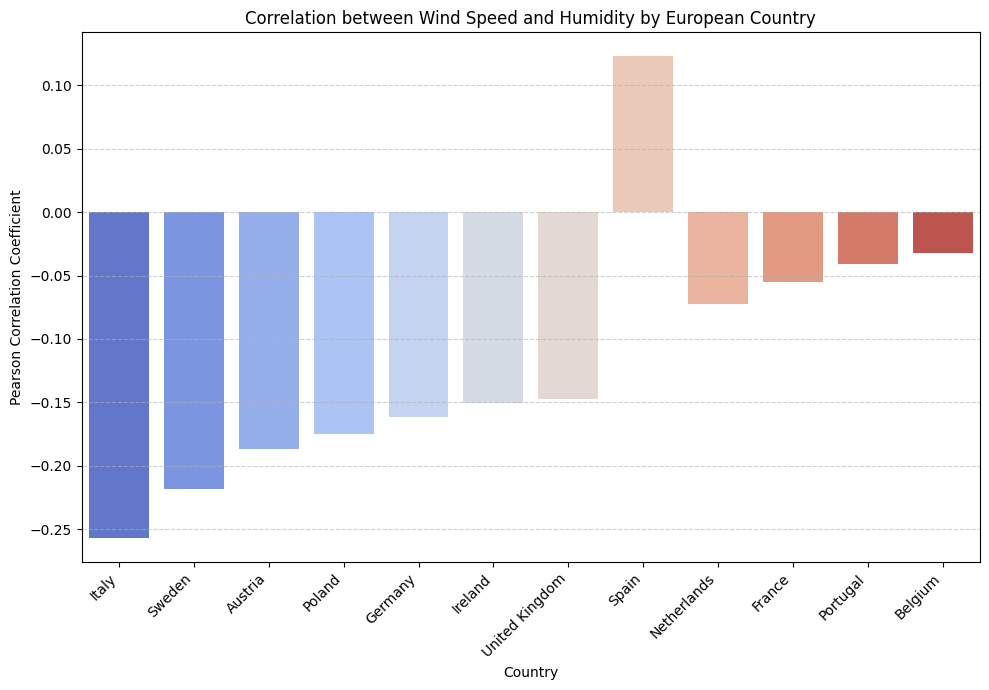

In [ ]:
import pandas as pd

# Ensure eu_df is available
if 'eu_df' not in locals() or eu_df.empty:
    if 'european_countries' not in locals():
        european_countries = [
            'United Kingdom', 'France', 'Germany', 'Spain', 'Italy',
            'Netherlands', 'Belgium', 'Sweden', 'Poland', 'Austria',
            'Portugal', 'Ireland'
        ]
    eu_df = df[df['country'].isin(european_countries)].copy()
    eu_df['last_updated'] = pd.to_datetime(eu_df['last_updated'])

# Calculate the correlation between wind_kph and humidity for each country
correlation_wh = eu_df.groupby('country')[['wind_kph', 'humidity']].corr().unstack().iloc[:, 1]

# Sort by the absolute value of the correlation to find the strongest relationships
correlation_wh_sorted = correlation_wh.reindex(correlation_wh.abs().sort_values(ascending=False).index)

print("Correlation between Wind Speed (kph) and Humidity (%) for European Countries (Sorted by strength):")
print(correlation_wh_sorted)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.barplot(x=correlation_wh_sorted.index, y=correlation_wh_sorted.values, palette='coolwarm')
plt.title('Correlation between Wind Speed and Humidity by European Country')
plt.xlabel('Country')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'last_updated' is in datetime format (if not already)
# This was done earlier, but adding a check for robustness
if not pd.api.types.is_datetime64_any_dtype(df['last_updated']):
    df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract month and assign season
df['month'] = df['last_updated'].dt.month
# Assuming Northern Hemisphere seasons for simplicity
def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'
df['season'] = df['month'].apply(get_season)

# Calculate average precipitation by month
avg_precip_month = df.groupby('month')['precip_mm'].mean().reset_index()

# Calculate average precipitation by season
# Define the order for seasons for correct plotting
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
avg_precip_season = df.groupby('season')['precip_mm'].mean().reindex(season_order).reset_index()

print("\nAverage Precipitation (mm) by Month:")
print(avg_precip_month)

print("\nAverage Precipitation (mm) by Season:")
print(avg_precip_season)


Average Precipitation (mm) by Month:
    month  precip_mm
0       1   0.122429
1       2   0.105888
2       3   0.118704
3       4   0.129513
4       5   0.151895
5       6   0.139808
6       7   0.167213
7       8   0.153617
8       9   0.152977
9      10   0.128500
10     11   0.136274
11     12   0.111179

Average Precipitation (mm) by Season:
   season  precip_mm
0  Winter   0.113345
1  Spring   0.134134
2  Summer   0.153535
3  Autumn   0.139144


/tmp/ipykernel_16275/1500682011.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='precip_mm', data=avg_precip_month, palette='Blues', ax=axes[0])
/tmp/ipykernel_16275/1500682011.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='precip_mm', data=avg_precip_season, palette='Greens', ax=axes[1])


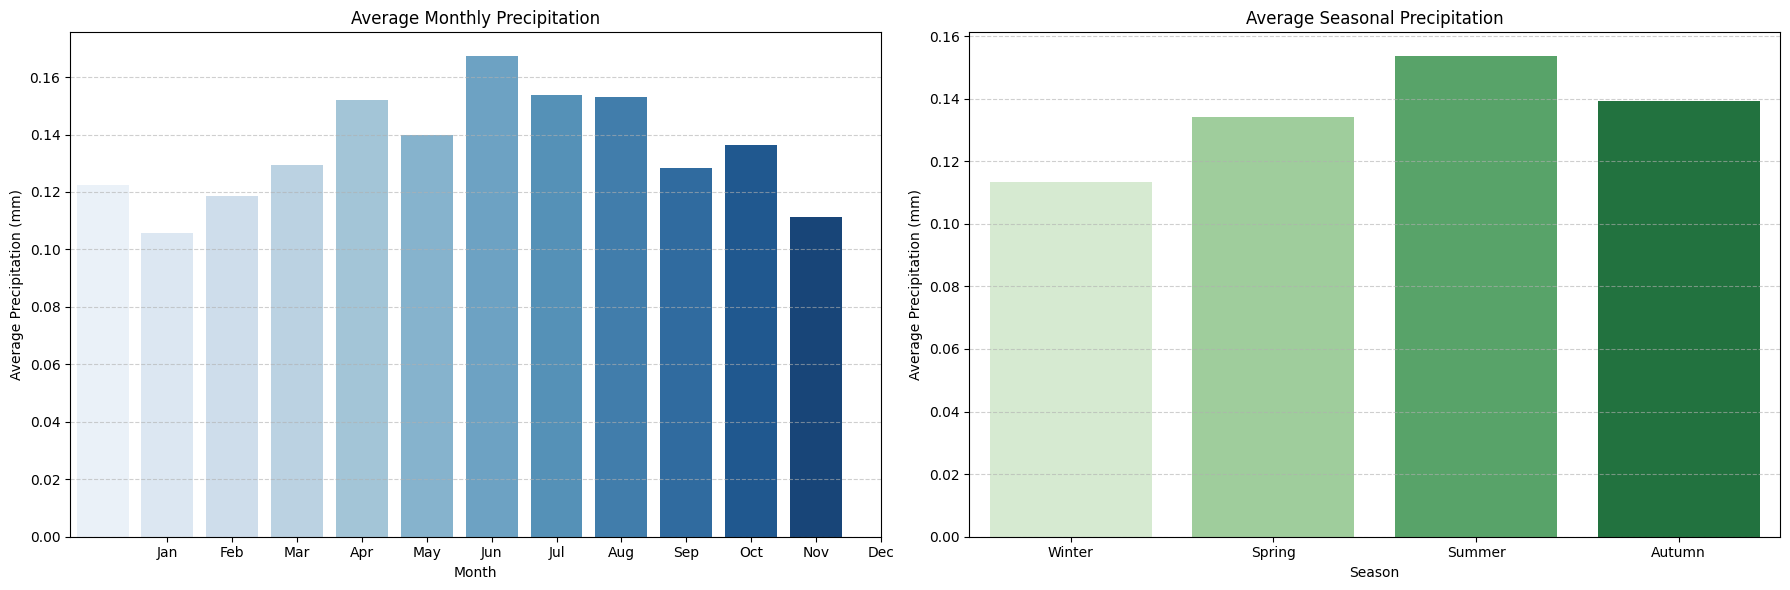

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Monthly Precipitation
sns.barplot(x='month', y='precip_mm', data=avg_precip_month, palette='Blues', ax=axes[0])
axes[0].set_title('Average Monthly Precipitation')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Precipitation (mm)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Plot for Seasonal Precipitation
sns.barplot(x='season', y='precip_mm', data=avg_precip_season, palette='Greens', ax=axes[1])
axes[1].set_title('Average Seasonal Precipitation')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Precipitation (mm)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()